In [3]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [4]:
dfs = []
for method in [2, 3]:
    directory = f'processed_results/{method}'
    subdirs = [root for root, dirs, files in os.walk(directory)][1:]

    for subdir in subdirs:
        for file in os.listdir(subdir):
            filepath = os.path.join(subdir, file)
            df = pd.read_csv(filepath)        # read CSV normally

            df['ward_code'] = file.split("-")[-2]
            df['method'] = method
            # Reindex to rounds 1–13, keep Round as a column
            df["Round"] = pd.to_numeric(df["Round"], errors="coerce")
            df[["Exhausted", "% Exhausted"]] = df[["Exhausted", "% Exhausted"]].fillna(0)
            df["Cumulative Exhausted"] = df["Exhausted"].cumsum()
            df["% Cumulative"] = df["% Exhausted"].cumsum()

            if '12' in subdir:
                df["year"] = 2012
            elif '17' in subdir:
                df["year"] = 2017
            elif '22' in subdir:
                df["year"] = 2022   
            
            dfs.append(df)

    exhaustion_results = pd.concat(dfs, ignore_index=True)

    # Aggregate by ward_code, method, and year
    exhaustion_results = exhaustion_results.groupby(['ward_code', 'method', 'year']).agg(cumulative_exhaustion=('% Cumulative', 'max')).reset_index()
    # Round cumulative_max
    exhaustion_results = exhaustion_results.round({'Cumulative_max': 3})
    exhaustion_results = exhaustion_results.set_index("ward_code")

    religion_db = pd.read_csv("raw_census_data/uv205_religion.csv")
    religion_db = religion_db.set_index("Electoral Ward 2022")

    exhaustion_results = exhaustion_results.join(religion_db[["percentage_christian"]])

    age_db = pd.read_csv("raw_census_data/uv102b_age.csv")
    age_db = age_db.set_index("Electoral Ward 2022")
    exhaustion_results = exhaustion_results.join(age_db[["pct_over_65"]])

    sex_db = pd.read_csv("raw_census_data/uv102b_sex.csv")
    sex_db = sex_db.set_index("Electoral Ward 2022")
    sex_db["pct_women"] = sex_db["pct_women"] - 0.5
    exhaustion_results = exhaustion_results.join(sex_db[["pct_women"]])

    marital_db = pd.read_csv("raw_census_data/uv104_maritalstatus.csv")
    marital_db = marital_db.set_index("Electoral Ward 2022")
    exhaustion_results = exhaustion_results.join(marital_db[["pct_married_or_widowed"]])

    educated_db = pd.read_csv("raw_census_data/uv501_education.csv")
    educated_db = educated_db.set_index("Electoral Ward 2022")
    exhaustion_results = exhaustion_results.join(educated_db[["pct_uni_educated"]])

    ranked_db = pd.read_csv("correlation.csv")
    ranked_db = ranked_db.set_index("ward_code")
    exhaustion_results = exhaustion_results.join(ranked_db)

    employed_db = pd.read_csv("raw_census_data/uv601_unemployment.csv")
    employed_db = employed_db.set_index("Electoral Ward 2022")
    exhaustion_results = exhaustion_results.join(employed_db[["pct_unemployed"]])

    pop_2017 = pd.read_excel(io="raw_census_data/2017_population_estimates.xlsx",sheet_name="2017")
    pop_2017 = pop_2017.set_index("Electoral Ward 2022 Code")
    pop_2017 = pop_2017.rename(columns={'Age 16 and over': 'electorate'})
    pop_2017 = pop_2017.rename(columns={"Electoral Ward 2022 code": "ward_code"})


    pop_2022 = pd.read_csv("raw_census_data/2022 electorate.csv")
    pop_2022["electorate"] = pop_2022["electorate"].astype(str).str.replace(",", "").astype(int)
    pop_2022 = pop_2022.set_index("ward_code")

    exh_2017 = exhaustion_results[exhaustion_results["year"] == 2017].join(pop_2017[["electorate"]])
    exh_2022 = exhaustion_results[exhaustion_results["year"] == 2022].join(pop_2022[["electorate"]])

    exhaustion_results = pd.concat([exh_2017, exh_2022]).sort_index()
    exhaustion_results["turnout"] = round(exhaustion_results["total_votes"] / exhaustion_results["electorate"],4)
    exhaustion_results["k/n"] = round(exhaustion_results["num_winners"] / exhaustion_results["num_candidates"],4)
    exhaustion_results.to_csv(f"results_{method}.csv")

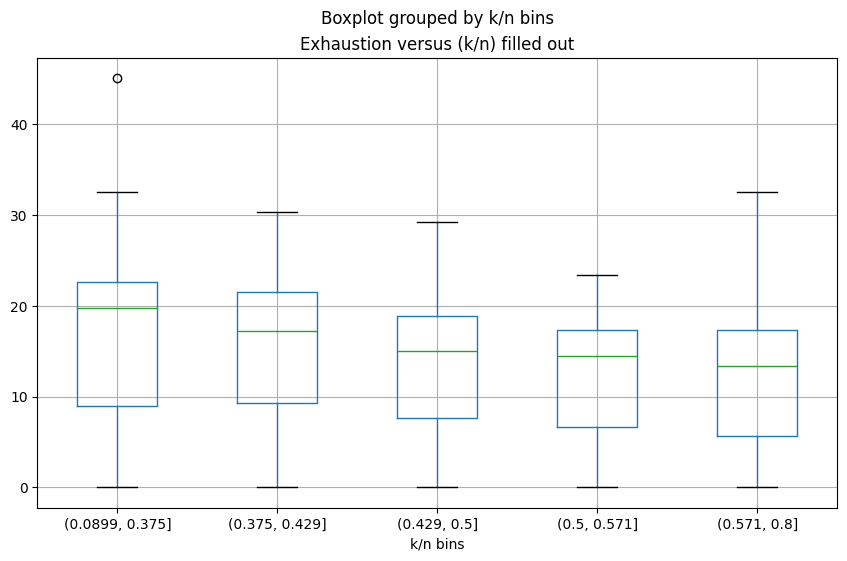

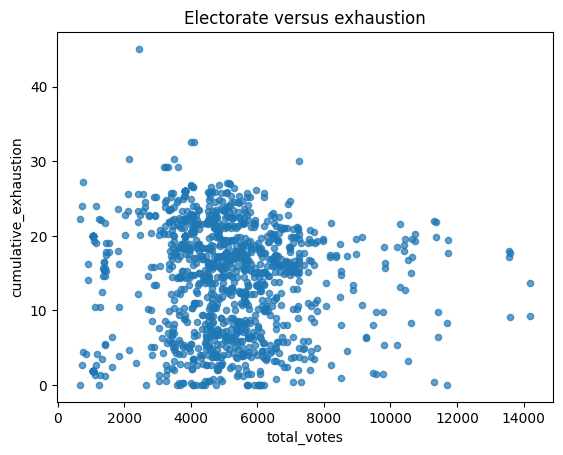

In [50]:
exhaustion_results = exhaustion_results[exhaustion_results["method"] == 0]
exhaustion_results['k/n bins'] = pd.qcut(exhaustion_results['k/n'], q=5)
exhaustion_results.boxplot(column="cumulative_exhaustion", by="k/n bins", figsize=[10,6])
plt.title("Exhaustion versus (k/n) filled out")
plt.show()
exhaustion_results.plot.scatter(x="total_votes", y="cumulative_exhaustion", alpha=0.7)  # alpha makes points slightly transparent
plt.title("Electorate versus exhaustion")
plt.show()
exhaustion_results.drop(columns="method")
corr_results = exhaustion_results.corr(numeric_only=True)